# Principal Components around FOMC Meetings

This notebook will exmaine Explained Variance of Principal Components for Yield Changes during FOMC meetings. The goal of this notebook is to corroborate a specific claim in the paper *The Pre-FOMC Drift and the Secular Decline in Long-Term Interest Rates* Whitepaper [here](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4764451). The hypothesis from the paper states that explained variances peak around FOMC events. The idea is that yields tend to move in tandom because the FOMC is an anchoring driver.

# Packages & Getting Data

In [1]:
import os
import sys
import numpy as np
import pandas as pd
from   sklearn.decomposition import PCA

import matplotlib.pyplot as plt
from   matplotlib.ticker import FuncFormatter

In [2]:
repo_path    = os.path.abspath(os.path.join(os.getcwd(), "..", ".."))
data_path    = os.path.join(repo_path, "data")
process_path = os.path.join(data_path, "ProcessedData")
raw_path     = os.path.join(data_path, "RawData")

In [3]:
date_path = os.path.join(process_path, "OrderedDates.parquet")
tsy_path  = os.path.join(raw_path, "TSYFredYields.parquet")

df_dates = pd.read_parquet(path = date_path, engine = "pyarrow")
df_tsy   = (pd.read_parquet(
    path = tsy_path, engine = "pyarrow").
    assign(date = lambda x: pd.to_datetime(x.date).dt.date).
    rename(columns = {
        "value"   : "yld",
        "val_diff": "yld_diff",
        "variable": "tenor"}).
    melt(id_vars = ["date", "tenor"]))

In [4]:
sentiment_path = os.path.join(raw_path, "SentimentData.parquet")
bad_securities = ['BENLPFPD', 'APUSXRGF']
df_sentiment   = (pd.read_parquet(
    path = sentiment_path, engine = "pyarrow").
    query("security != @bad_securities"))

# Principal Components around FOMC

In this case run PCA of returns on specific days of the FOMC event. The idea is that we collect the yield changes per each day relative to the FOMC announcement, then take the principal components, and measure the explained variance per component.

In [5]:
def _get_pc_importance(df: pd.DataFrame, num_components: int = 2) -> pd.DataFrame: 

    df_tmp = (df[
        ["date", "tenor", "value"]].
        drop_duplicates().
        pivot(index = "date", columns = "tenor", values = "value").
        dropna())
    
    exp_var = (PCA(
        n_components = num_components).
        fit(df_tmp).
        explained_variance_ratio_)

    df_out = (pd.DataFrame({
        "comp"   : ["PC{}".format(i + 1) for i in range(num_components)],
        "exp_var": exp_var}))

    return df_out

df_exp_var = (df_tsy.merge(
    right = df_dates, how=  "inner", on = ["date"]).
    assign(tmp = lambda x: x.variable + " " + x.day.astype(str)).
    groupby("tmp").
    apply(_get_pc_importance, include_groups = False).
    reset_index().
    drop(columns = ["level_1"]).
    assign(
        variable = lambda x: x.tmp.str.split(" ").str[0],
        days     = lambda x: x.tmp.str.split(" ").str[1].astype(float)).
    drop(columns = ["tmp"]))

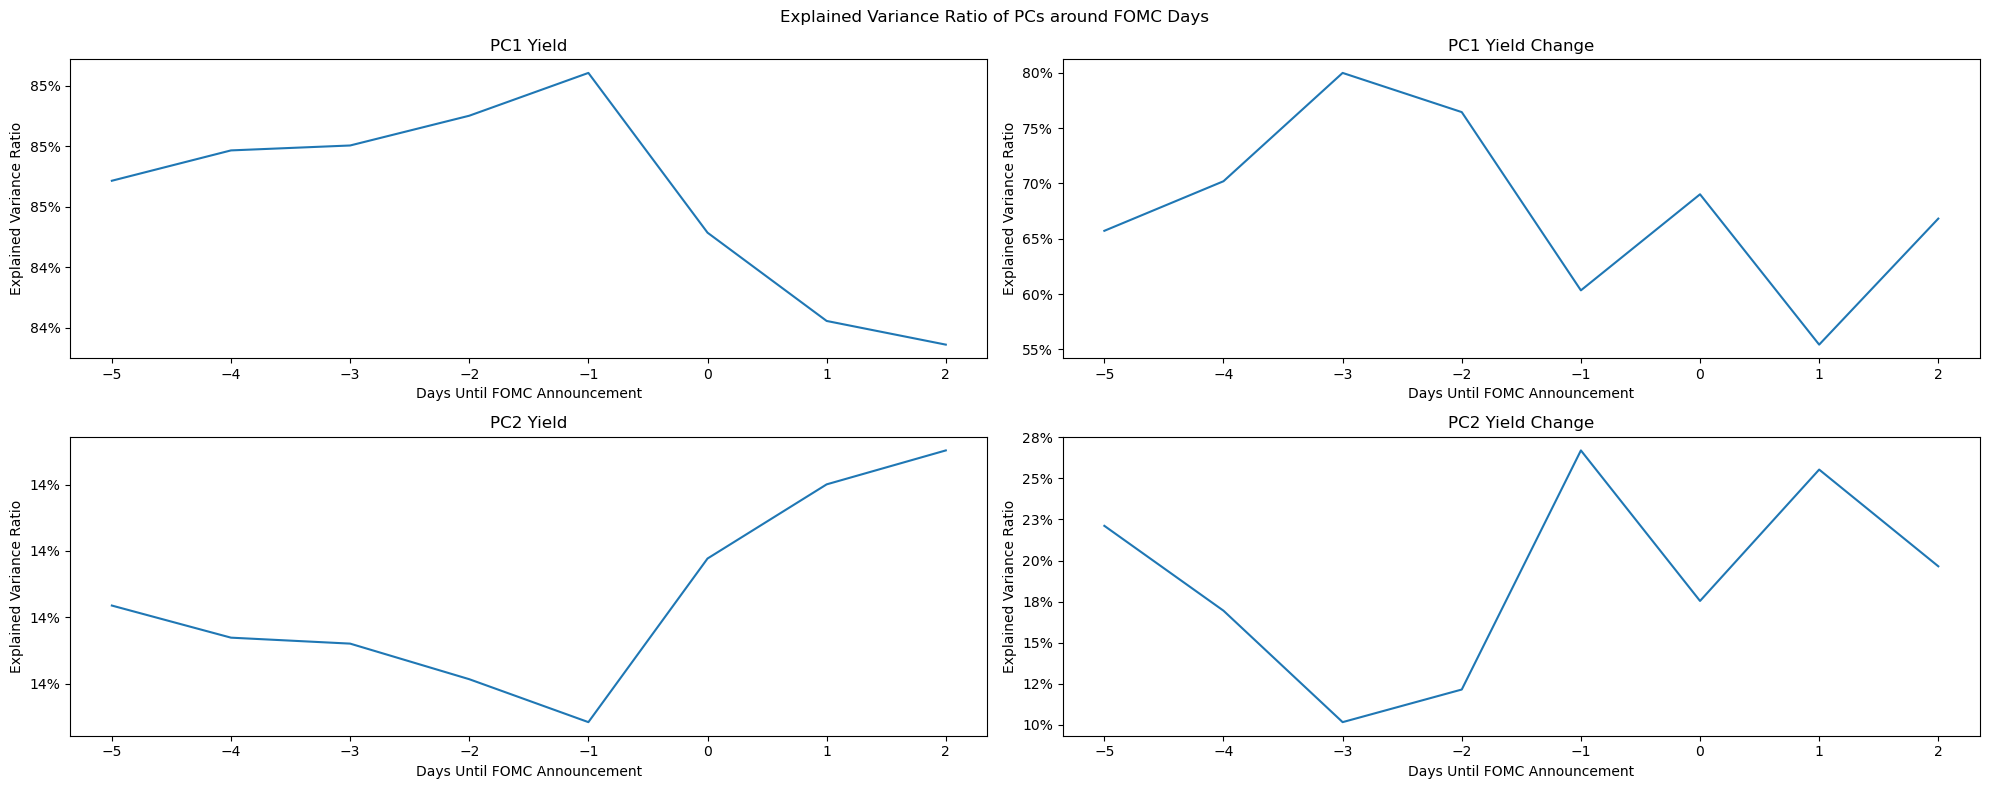

In [6]:
df_tmp = (df_exp_var.assign(
    group_var = lambda x: x.comp + " " + x.variable))

group_vars = df_tmp.group_var.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 2, nrows = len(group_vars) // 2, figsize = (20,8))

replacer = {
    "yld"     : "Yield",
    "yld_diff": "Yield Change"}

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_tmp.query(
        "group_var == @group_var").
        sort_values("days").
        set_index("days")
        [["exp_var"]].
        plot(
            ax     = ax,
            legend = False,
            xlabel = "Days Until FOMC Announcement",
            title  = group_var.split(" ")[0] + " " + replacer[group_var.split(" ")[1]],
            ylabel = "Explained Variance Ratio"))

    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x * 100:.0f}%'))

fig.suptitle("Explained Variance Ratio of PCs around FOMC Days")
plt.tight_layout()

In [7]:
def _get_full_pc(df: pd.DataFrame, n_comps: int = 2) -> pd.DataFrame: 

    df_input = (df.drop_duplicates().pivot(
        index = "date", columns = "tenor", values = "value").
        dropna())

    exp_var = (PCA(
        n_components = n_comps).
        fit(df_input).
        explained_variance_ratio_)

    df_out = (pd.DataFrame({
        "comp":    ["PC{}".format(i + 1) for i in range(n_comps)],
        "exp_var": exp_var}))

    return df_out

df_full = (df_tsy.groupby(
    "variable").
    apply(_get_full_pc, include_groups = False).
    reset_index().
    drop(columns = ["level_1"]).
    rename(columns = {"exp_var": "full_exp"}))

In [8]:
(df_exp_var.merge(
    right = df_full, how = "inner", on = ["comp", "variable"]).
    rename(columns = {"variable": "var_calc"}).
    melt(id_vars = ["comp", "var_calc", "days"]).
    assign(days = lambda x: x.days.astype(int)).
    replace({
        "yld"     : "Raw Yield",
        "yld_diff": "Yield Changes",
        "exp_var" : "Spef. Day",
        "full_exp": "Full Period"}).
    rename(columns = {
        "var_calc": "",
        "variable": "PCA Period",
        "days"    : "Days",
        "comp"    : "PC"}).
    pivot(index = ["Days", "PC"], columns = ["PCA Period", ""], values = "value").
    apply(lambda x: np.round(x,3)))

PCA Period Spef. Day               Full Period              
           Raw Yield Yield Changes   Raw Yield Yield Changes
Days PC                                                     
-5   PC1       0.847         0.657       0.858         0.679
     PC2       0.140         0.221       0.129         0.178
-4   PC1       0.848         0.702       0.858         0.679
     PC2       0.139         0.169       0.129         0.178
-3   PC1       0.848         0.800       0.858         0.679
     PC2       0.139         0.102       0.129         0.178
-2   PC1       0.849         0.765       0.858         0.679
     PC2       0.138         0.122       0.129         0.178
-1   PC1       0.850         0.603       0.858         0.679
     PC2       0.137         0.267       0.129         0.178
 0   PC1       0.845         0.690       0.858         0.679
     PC2       0.142         0.175       0.129         0.178
 1   PC1       0.842         0.554       0.858         0.679
     PC2       0.144         0.255       0.129         0.178
 2   PC1       0.841         0.668       0.858         0.679
     PC2       0.145         0.196       0.129         0.178

# Principal Components: Conditioned on FOMC Sentiment

In [9]:
window    = 10
df_zscore = (df_sentiment.pivot(
    index = "date", columns = "security", values = "value").
    apply(lambda x: (x - x.ewm(span = window, adjust = False).mean()) / x.ewm(span = window, adjust = False).std()).
    reset_index().
    melt(id_vars = "date", value_name = "z_score"))

In [10]:
df_combined = (df_tsy.merge(
    right = df_dates, how = "inner", on = ["date"]))

In [11]:
df_condition = (df_combined.query(
    "day == -3")
    [["date", "day", "event"]].
    drop_duplicates().
    merge(right = df_zscore, how = "inner", on = ["date"]).
    dropna().
    assign(condition = lambda x: np.where(x.z_score > 0, "pos", "neg")).
    drop(columns = ["date", "day"]))

In [12]:
df_input = (df_combined.merge(
    right = df_condition, how = "inner", on = ["event"]).
    assign(tmp = lambda x: x.variable + " " + x.condition + " " + x.security + " " + x.day.astype(str)))

df_namer = (df_input[
    ["tmp", "variable", "condition", "security", "day"]].
    drop_duplicates())

In [13]:
df_conditioned_pca = (df_input.
    groupby("tmp").
    apply(_get_pc_importance, include_groups = False).
    reset_index().
    drop(columns = ["level_1"]).
    merge(right = df_namer, how = "inner", on = ["tmp"]))

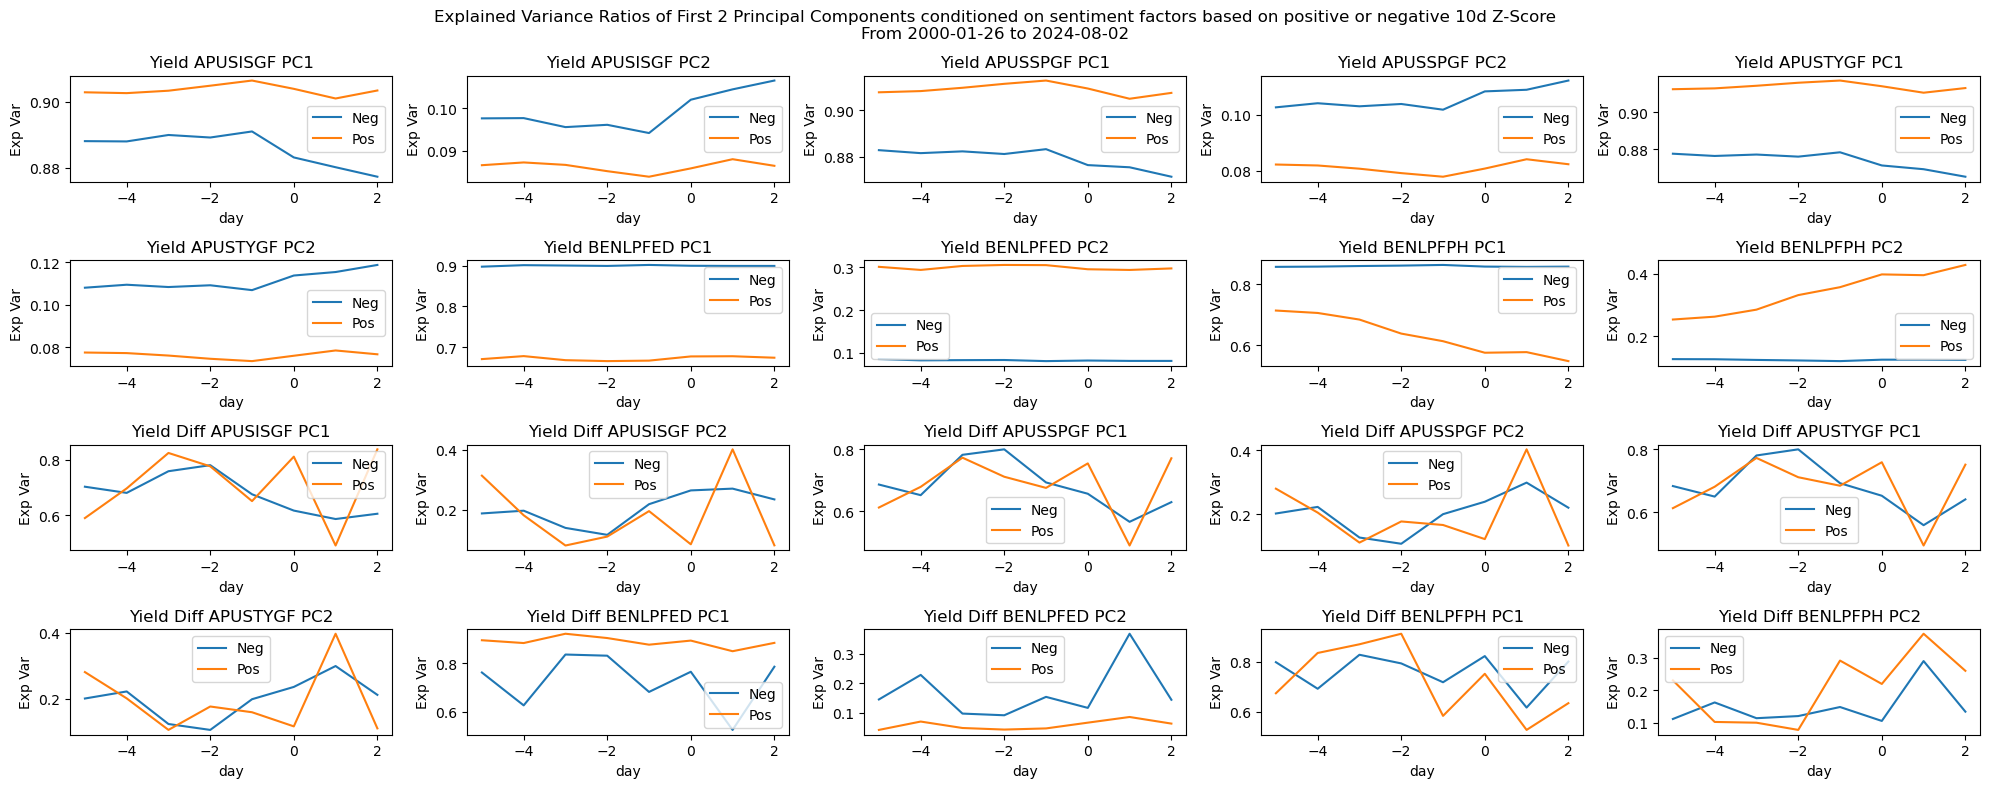

In [14]:
df_plot = (df_conditioned_pca.assign(
    tmp = lambda x: x.variable + " " + x.security + " " + x.comp))

group_vars = df_plot.tmp.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 4, nrows = len(group_vars) // 5, figsize = (20,8))

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_plot.query(
        "tmp == @group_var").
        assign(condition = lambda x: x.condition.str.capitalize()).
        rename(columns = {"condition": ""}).
        pivot(index = "day", columns = "", values = "exp_var").
        plot(
            ax     = ax,
            ylabel = "Exp Var",
            title  = group_var.replace("yld_diff", "Yield Diff").replace("yld", "Yield")))

fig.suptitle("Explained Variance Ratios of First 2 Principal Components conditioned on sentiment factors based on positive or negative 10d Z-Score\nFrom {} to {}".format(
    df_combined.date.min(),
    df_combined.date.max()))
plt.tight_layout()

# Treasury Yields around FOMC Dates

In [15]:
tmp_tenors = ['DGS5', 'DGS5', 'DGS7', 'DGS10', 'DGS30']
df_tsy_tmp = (df_tsy.query(
    "tenor == @tmp_tenors").
    query("variable == 'yld_diff'"))

In [16]:
def get_ylds_around(df_dates: pd.DataFrame, df_tsy_tmp: pd.DataFrame, df_tsy: pd.DataFrame, days: list, name: str) -> pd.DataFrame:

    df_yld_tmp = (df_dates.query(
        "day == @days").
        merge(right = df_tsy_tmp, how = "inner", on = ["date"])
        [["date", "tenor", "value"]].
        drop_duplicates().
        pivot(index = "date", columns = "tenor", values = "value").
        cumsum().
        reset_index().
        melt(id_vars = "date"))
    
    df_day_start = (df_yld_tmp[
        ["date", "tenor"]].
        groupby("tenor").
        agg("min").
        assign(variable = "yld").
        reset_index().
        merge(right = df_tsy, how = "inner", on = ["date", "variable", "tenor"]).
        rename(columns = {"value": "start_val"}).
        drop(columns = ["variable", "date"]))
    
    df_out = (df_day_start.merge(
        right = df_yld_tmp, how = "inner", on = ["tenor"]).
        assign(
            name    = name,
            adj_val = lambda x: x.value + x.start_val)
        [["tenor", "date", "adj_val", "name", "value"]])

    return df_out

In [17]:
df_zero = get_ylds_around(df_dates, df_tsy_tmp, df_tsy, days = [0], name = "zero")
df_ones = get_ylds_around(df_dates, df_tsy_tmp, df_tsy, days = [-1,0,1], name = "ones")
df_before = get_ylds_around(df_dates, df_tsy_tmp, df_tsy, days = [-3,-2,-1], name = "before")

In [18]:
df_full = (df_tsy.query(
    "variable == 'yld'").
    query("tenor == @tmp_tenors").
    drop(columns = ["variable"]).
    rename(columns = {"value": "adj_val"}).
    assign(name = "full"))

In [19]:
df_combined = (pd.concat([df_zero, df_ones, df_full, df_before]))

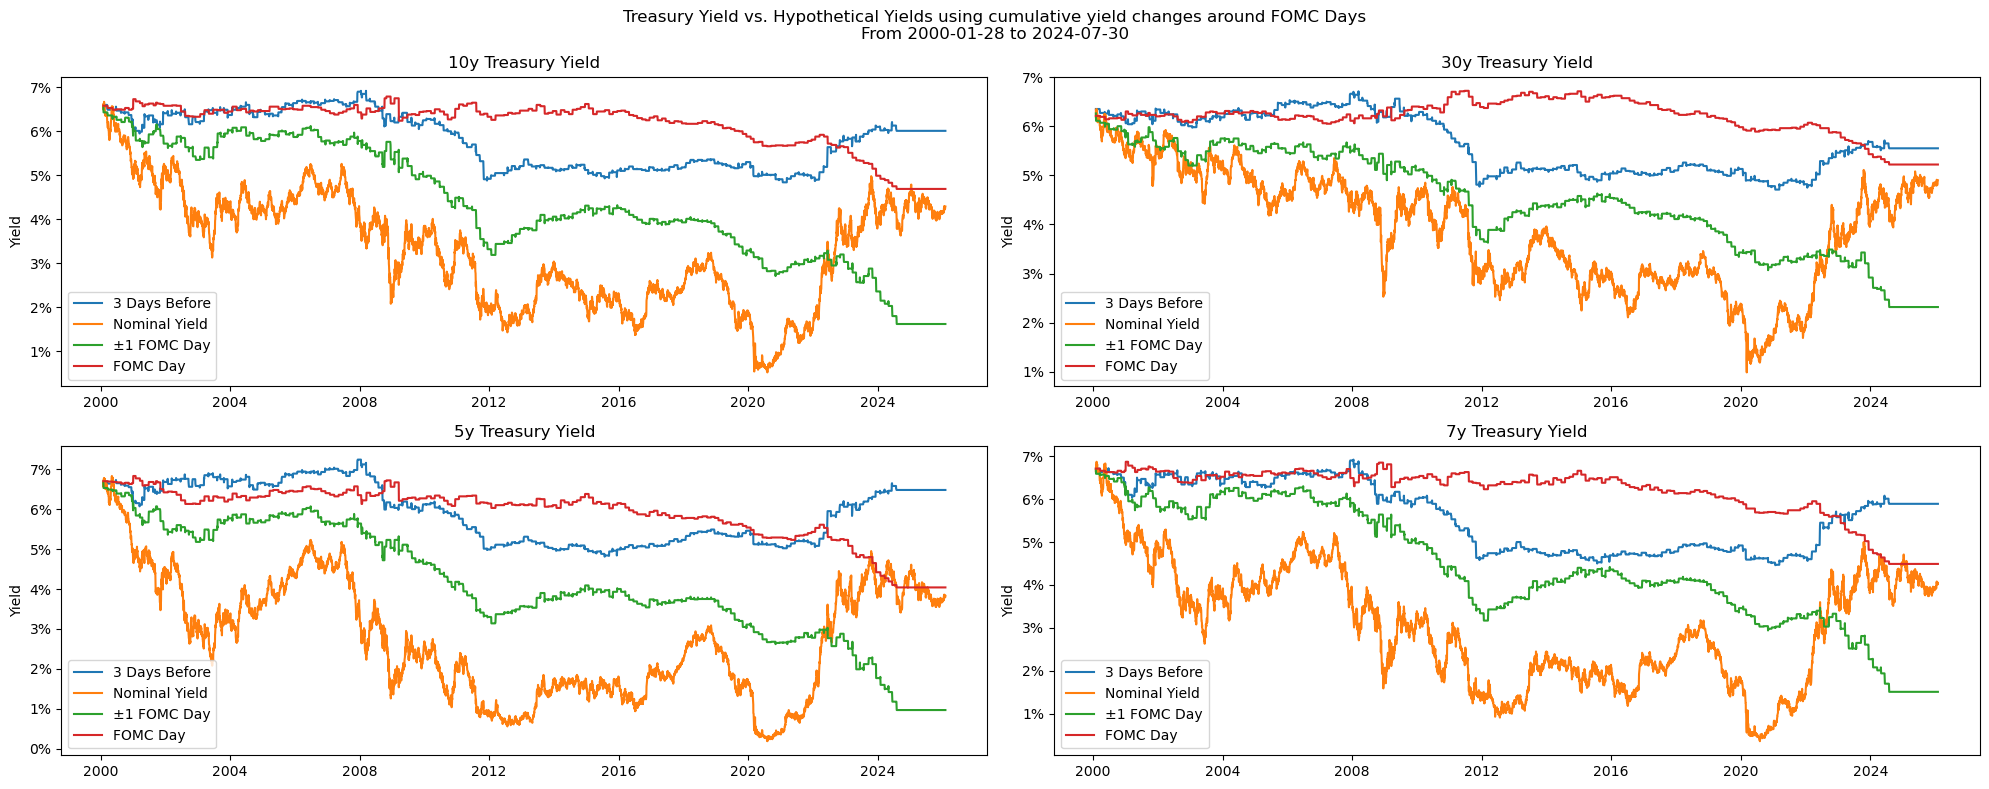

In [20]:
group_vars = df_combined.tenor.drop_duplicates().sort_values().to_list()
fig, axes  = plt.subplots(ncols = len(group_vars) // 2, nrows = len(group_vars) // 2, figsize = (20,8))

renamer = {
    "DGS5": "5y",
    "DGS7": "7y",
    "DGS10": "10y",
    "DGS30": "30y"}

calc_renamer = {
    "full"  : "Nominal Yield",
    "ones"  : "±1 FOMC Day",
    "zero"  : "FOMC Day",
    "before": "3 Days Before"}

for group_var, ax in zip(group_vars, axes.flatten()): 

    (df_combined.query(
        "tenor == @group_var").
        rename(columns = {"name": ""}).
        pivot(index = "date", columns = "", values = "adj_val").
        rename(columns = calc_renamer).
        ffill().
        dropna().
        plot(
            ax = ax,
            xlabel = "",
            ylabel = "Yield",
            title  = renamer[group_var] + " Treasury Yield"))

    ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f'{x/100:.0%}'))

fig.suptitle("Treasury Yield vs. Hypothetical Yields using cumulative yield changes around FOMC Days\nFrom {} to {}".format(
    df_before.date.min(),
    df_before.date.max()))
plt.tight_layout()

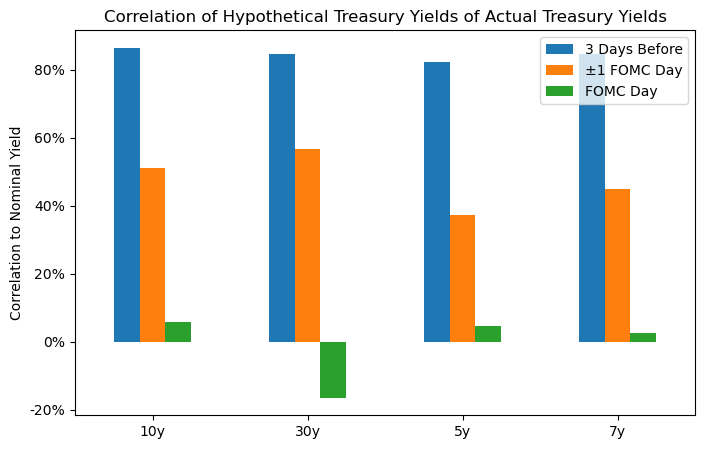

In [21]:
fig, axes = plt.subplots(figsize = (8,5))

(df_combined.pivot(
    index = "date", columns = ["tenor", "name"], values = "adj_val").
    ffill().
    dropna().
    reset_index().
    melt(id_vars = [("date", "")]).
    rename(columns = {("date", ""): "date"}).
    pivot(index = ["date", "tenor"], columns = "name", values = "value").
    reset_index().
    melt(id_vars = ["date", "tenor", "full"]).
    drop(columns = ["date"]).
    groupby(["tenor", "name"]).
    agg("corr").
    drop(columns = ["value"]).
    query("full != 1").
    reset_index().
    rename(columns = {"name": ""}).
    replace(renamer).
    pivot(index = "tenor", columns = "", values = "full").
    rename(columns = calc_renamer).
    plot(
        kind    = "bar",
        rot     = 0,
        ylabel  = "Correlation to Nominal Yield",
        title   = "Correlation of Hypothetical Treasury Yields of Actual Treasury Yields",
        xlabel  = "",
        ax      = axes))

axes.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v * 100:.0f}%"))